# Analysis of Sample OREX-800107-0: Analysis of Axis Ratios

In [142]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

Reading the CSV file for further particle shape analysis:
--------------------------------------------------

In [145]:
# read the CSV file containing all the axes
InertiaAxes = pd.read_csv('ParticleAxes.csv', delimiter=',')

In [147]:
ParticleIDs = InertiaAxes['ParticleID'].unique()
print(f"Number of total particles: {len(ParticleIDs)}")

Number of total particles: 30699


In [149]:
# clear the undesired particles from the CSV 
# (any particles less than what was added to account for the erosion in dragonfly)
InertiaAxes = InertiaAxes[(InertiaAxes['Long'] > 0.068) &
        (InertiaAxes['Intermediate'] > 0.068) &
        (InertiaAxes['Short'] > 0.068)]

In [151]:
# ensure that the inertia method is not producing the same error as PCA method was

bad_rows = InertiaAxes[InertiaAxes['Intermediate'] > InertiaAxes['Long']]

print(bad_rows)
print(f"number of invalid rows for int vs. long: {len(bad_rows)}")

bad_rows2 = InertiaAxes[InertiaAxes['Short'] > InertiaAxes['Intermediate']]

print(bad_rows2)
print(f"number of invalid rows for short vs. int: {len(bad_rows2)}")

Empty DataFrame
Columns: [ParticleID, Long, Intermediate, Short]
Index: []
number of invalid rows for int vs. long: 0
Empty DataFrame
Columns: [ParticleID, Long, Intermediate, Short]
Index: []
number of invalid rows for short vs. int: 0


In [153]:
# from output statement: only 15 particles had an invalid voxel count from Dragonfly
ParticleIDs = InertiaAxes['ParticleID'].unique()
print(f"Number of particles for analysis: {len(ParticleIDs)}")

Number of particles for analysis: 30684


Axis Ratios:
------------

In [156]:
LongestAxis = InertiaAxes['Long'].values
IntAxis = InertiaAxes['Intermediate'].values
ShortestAxis = InertiaAxes['Short'].values

In [158]:
# make new csv for the axis ratios with the other axis data
# we want ratio of (1) shortest axis to longest axis and (2) intermediate axis to longest axis (Tachibana+2022)

InertiaAxes['I/L'] = InertiaAxes['Intermediate'] / InertiaAxes['Long']
InertiaAxes['S/L'] = InertiaAxes['Short'] / InertiaAxes['Long']

# save to new CSV file
output_file = "OREX-800107-0_ParticleAxes_withRatios.csv"
InertiaAxes.to_csv(output_file, index=False)

print(f"Saved updated file with axis ratios to: {output_file}")

Saved updated file with axis ratios to: OREX-800107-0_ParticleAxes_withRatios.csv


In [160]:
# read the CSV with the axis ratios included
AxisRatios = pd.read_csv('OREX-800107-0_ParticleAxes_withRatios.csv', delimiter=',')

In [162]:
I_to_L = AxisRatios['I/L'].values
S_to_L = AxisRatios['S/L'].values

In [164]:
# compute the average axis ratios for each ratio
Avg_IL = np.average(I_to_L)
Avg_SL = np.average(S_to_L)

Plotting the axis ratios:
------------------------

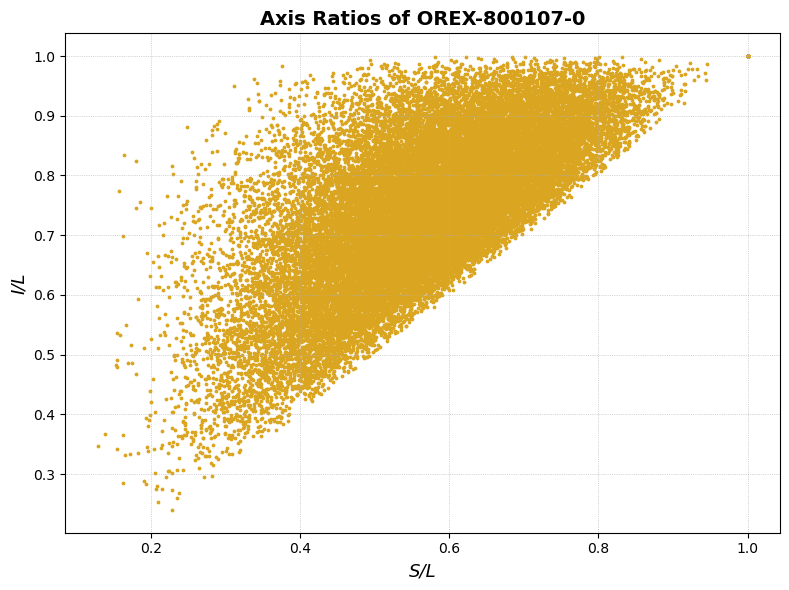

In [167]:
plt.figure(figsize=(8,6))
plt.scatter(S_to_L, I_to_L, color='goldenrod', s=3)

# labels and organization
plt.xlabel("S/L", fontsize=13).set_style('italic')
plt.ylabel("I/L", fontsize=13).set_style('italic')
plt.title("Axis Ratios of OREX-800107-0", fontsize=14, weight='bold')

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.savefig('OREX-800107-0_AxisRatios.png')
plt.show()

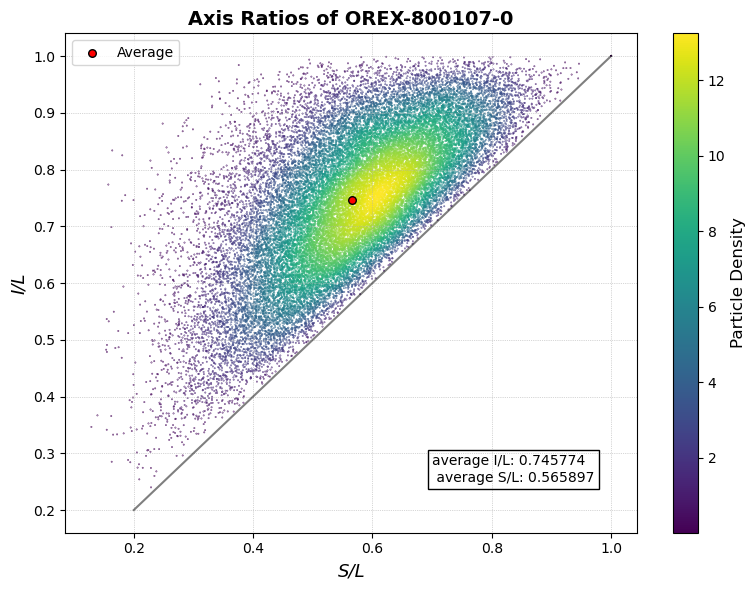

In [126]:
# plot the axis ratios with a color bar to show particle density

# convert data to arrays
x = np.array(S_to_L)
y = np.array(I_to_L)

# compute data density using SciPy
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# sort points by particle density
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# compute the mean value
mean_x = np.mean(x)
mean_y = np.mean(y)

plt.figure(figsize=(8,6))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=0.1)

# add the color bar to show density
cbar = plt.colorbar(sc)
cbar.set_label('Particle Density', fontsize=12)

# plot y=x to see if axis ratios are correct
x_line = np.linspace(0.2, 1, 100)
y_line = x_line
plt.plot(x_line, y_line, color='black', alpha=0.5)

# plot the mean value
plt.scatter(mean_x, mean_y, color='red', s=30, edgecolor='black', label='Average')

plt.xlabel("S/L", fontsize=13, style='italic')
plt.ylabel("I/L", fontsize=13, style='italic')
plt.title("Axis Ratios of OREX-800107-0", fontsize=14, weight='bold')

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.text(0.7,0.25,f"average I/L: {mean_y:3f}\n average S/L: {mean_x:3f}", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))
plt.legend()
plt.tight_layout()

plt.savefig('OREX-800107-0_AxisRatios_with_average.png', dpi=300)
plt.show()

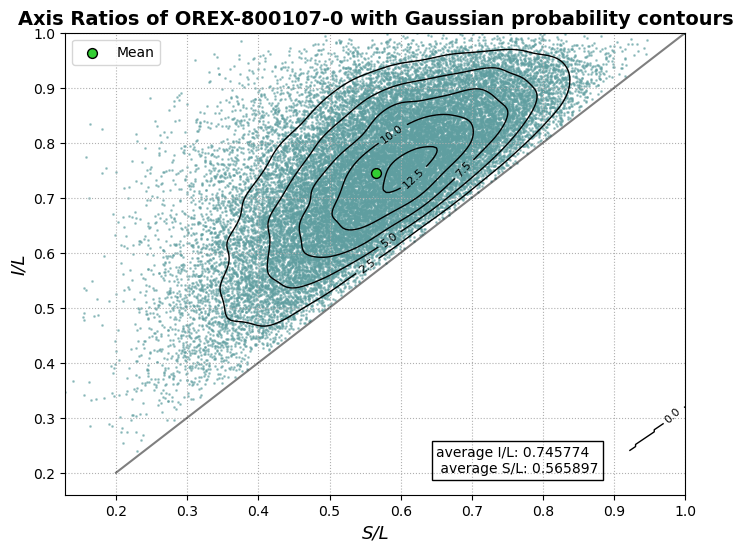

In [128]:
# create a grid
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])

# KDE
kde = gaussian_kde(np.vstack([x, y]))
Z = np.reshape(kde(positions).T, X.shape)

plt.figure(figsize=(8,6))
plt.scatter(x, y, s=1, color='cadetblue', alpha=0.5)

# contour lines at probability levels
contours = plt.contour(X, Y, Z, levels=5, colors="black", linewidths=1)
plt.clabel(contours, inline=True, fontsize=8)

# plot y=x to see if axis ratios are correct
x_line = np.linspace(0.2, 1, 100)
y_line = x_line
plt.plot(x_line, y_line, color='black', alpha=0.5)

# plot mean point
plt.scatter(mean_x, mean_y, color="limegreen", edgecolor="black", s=50, label="Mean")

plt.xlabel("S/L", fontsize=13, style='italic')
plt.ylabel("I/L", fontsize=13, style='italic')
plt.title("Axis Ratios of OREX-800107-0 with Gaussian probability contours", fontsize=14, weight='bold')
plt.grid(True, linestyle=":")
plt.text(0.65,0.2,f"average I/L: {mean_y:3f}\n average S/L: {mean_x:3f}", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))
plt.legend()

plt.savefig('OREX-800107-0_AxisRatios_with_GaussianProb.png', dpi=300)
plt.show()

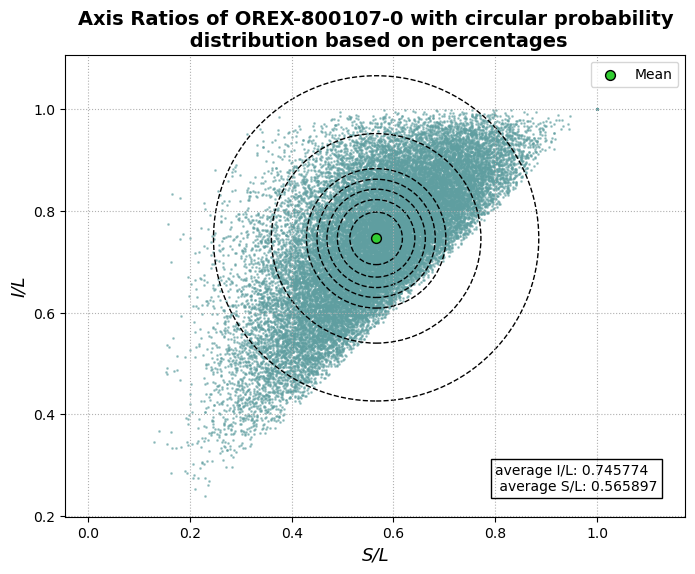

In [129]:
x = np.array(S_to_L)
y = np.array(I_to_L)

# compute mean
mean_x, mean_y = np.mean(x), np.mean(y)

# compute distance of each point from the mean
r = np.sqrt((x - mean_x)**2 + (y - mean_y)**2)

# quantile radii for circles (like probability levels)
radii = np.quantile(r, [0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 0.95]) 

plt.figure(figsize=(8,6))
plt.scatter(x, y, s=1, color='cadetblue', alpha=0.5)

# plot concentric circles for probability
for q, radius in zip([0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 0.95], radii):
    circle = plt.Circle((mean_x, mean_y), radius, color="black", fill=False, linestyle="--")
    plt.gca().add_patch(circle)

# plot the mean
plt.scatter(mean_x, mean_y, color="limegreen", edgecolor="black", s=50, label="Mean")

plt.xlabel("S/L", fontsize=13, style='italic')
plt.ylabel("I/L", fontsize=13, style='italic')
plt.title("Axis Ratios of OREX-800107-0 with circular probability\n distribution based on percentages", fontsize=14, weight='bold')
plt.grid(True, linestyle=":")
plt.text(0.8,0.25,f"average I/L: {mean_y:3f}\n average S/L: {mean_x:3f}", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))
plt.legend()
plt.axis("equal")  # keep circles circular

plt.savefig('OREX-800107-0_AxisRatios_with_PercentageProb.png', dpi=300)
plt.show()

Notes on the above plotted axis ratios:
- From Michikami+2015: b/a was ~ 0.735 and c/a was ~ 0.455 (from the fragmented particles)

Plotting the histograms:
-----------------------

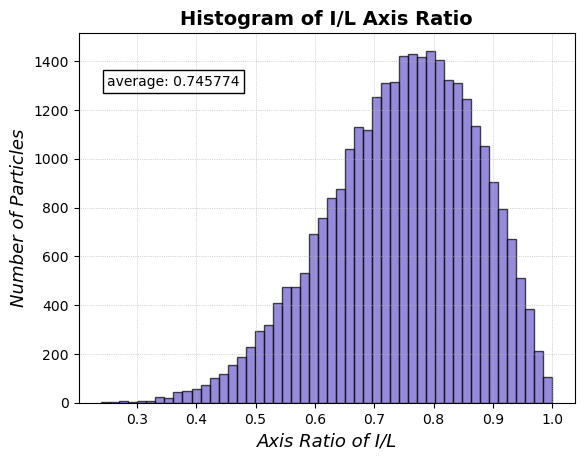

In [138]:
plt.hist(I_to_L, bins=50, color='slateblue', edgecolor='black', alpha=0.7)

plt.xlabel("Axis Ratio of I/L", fontsize=13, style='italic')
plt.ylabel("Number of Particles", fontsize=13, style='italic')
plt.title("Histogram of I/L Axis Ratio", fontsize=14, weight='bold')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.text(0.25,1300,f"average: {mean_y:3f}", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))

plt.savefig('OREX-800107-0_I_to_L_Histogram.png', dpi=300)
plt.show()

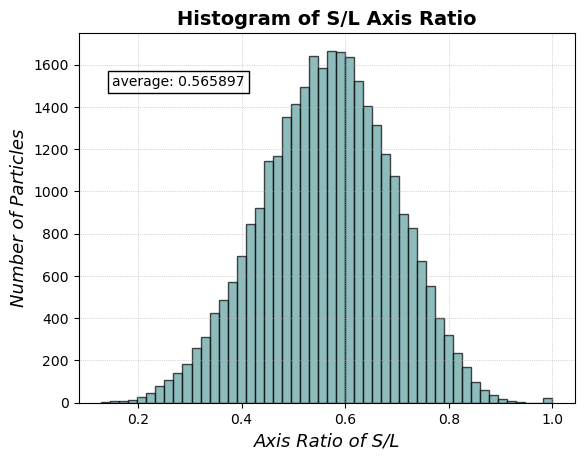

In [140]:
plt.hist(S_to_L, bins=50, color='cadetblue', edgecolor='black', alpha=0.7)

plt.xlabel("Axis Ratio of S/L", fontsize=13, style='italic')
plt.ylabel("Number of Particles", fontsize=13, style='italic')
plt.title("Histogram of S/L Axis Ratio", fontsize=14, weight='bold')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.text(0.15,1500,f"average: {mean_x:3f}", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))

plt.savefig('OREX-800107-0_S_to_L_Histogram.png', dpi=300)
plt.show()